In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("emmarex/plantdisease")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'plantdisease' dataset.
Path to dataset files: /kaggle/input/plantdisease


In [ ]:
import os

# List the folders inside the dataset path
folders = os.listdir(path)
print(folders)
# Example: looking into the first folder found
subfolder = os.path.join(path, folders[0])
print(f"Files in {folders[0]}:", os.listdir(subfolder)[:5])

['PlantVillage', 'plantvillage']
Files in PlantVillage: ['Pepper__bell___Bacterial_spot', 'Potato___healthy', 'Tomato_Leaf_Mold', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato_Bacterial_spot']


cuda
Using Colab cache for faster access to the 'plantdisease' dataset.
Epoch : 1 & Loss : 123.01
Epoch : 2 & Loss : 83.80
Epoch : 3 & Loss : 67.97
Epoch : 4 & Loss : 58.38
Epoch : 5 & Loss : 52.24
Epoch : 6 & Loss : 46.32
Epoch : 7 & Loss : 42.40
Epoch : 8 & Loss : 39.31
Epoch : 9 & Loss : 37.24
Epoch : 10 & Loss : 35.22
Epoch : 11 & Loss : 32.35
Epoch : 12 & Loss : 30.99
Epoch : 13 & Loss : 30.61
Epoch : 14 & Loss : 30.00
Epoch : 15 & Loss : 30.31
Epoch : 16 & Loss : 27.32
Epoch : 17 & Loss : 26.73
Epoch : 18 & Loss : 25.25
Epoch : 19 & Loss : 25.41
Epoch : 20 & Loss : 24.37


Saving ptato.jpg to ptato.jpg


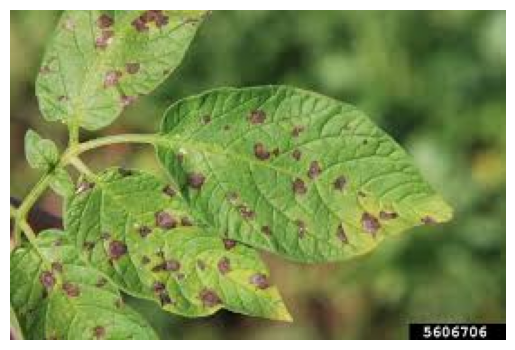

I Looked Carefully In The Image , And It Seems like To Be Your Crop is suffering from Potato___Early_blight
 Accuracy : 91.21


In [1]:
import kagglehub
from logging import root
import torch
import torch.nn as nn
import torch.nn.functional as f
import torch.optim as optim
from torchvision import datasets, transforms
from google.colab import files
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torch.utils.data import random_split
import matplotlib.pyplot as plt
import random
import os
from PIL import Image

from torchvision import transforms
from torchvision.datasets import ImageFolder

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)
transform = transforms.Compose([
    transforms.Resize(128),
    transforms.CenterCrop(128),
    transforms.ToTensor()

])


path = kagglehub.dataset_download("emmarex/plantdisease")


folders = os.listdir(path)
subfolder = os.path.join(path, folders[0])

dataset = ImageFolder(root=subfolder, transform=transform)
classes = dataset.classes

subset_size = 4890   # choose what you want

dataset, _ = random_split(
    dataset,
    [subset_size, len(dataset) - subset_size]
)



train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_data, test_data = random_split(
    dataset,
    [train_size, test_size]
)

train_loader = DataLoader(
    train_data,
    batch_size = 64,
    shuffle=True,
    num_workers = 0,
    pin_memory = False
)

test_loader = DataLoader(
    test_data,
    batch_size = 64,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)



class Plant(nn.Module):
  def __init__(self,num_classes) :
    super().__init__()

    self.features = nn.Sequential(

            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),



            nn.AdaptiveAvgPool2d((1, 1))
        )

    self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

  def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


epochs = 20
model = Plant(len(classes)).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer,step_size=5,gamma=0.5)

for epoch in range(epochs):
  model.train()
  total_loss = 0
  for images,labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)

    output = model(images)
    optimizer.zero_grad()
    loss = loss_fn(output,labels)
    loss.backward()
    optimizer.step()
    total_loss+=loss.item()
  scheduler.step()

  print(f"Epoch : {epoch+1} & Loss : {total_loss:.2f}")


model.eval()
correct=0
total = 0
with torch.no_grad():
 for images , labels in test_loader:
  images = images.to(device)
  labels = labels.to(device)

  output = model(images)
  _, predictions = torch.max(output,1)

  total+=labels.size(0)
  correct+=(predictions==labels).sum().item()
accuracy = 100 * correct/total

torch.save(model.state_dict(),"plant_disease_identifier.pth")

uploaded = files.upload()

img_name = list(uploaded.keys())[0]

img = Image.open(img_name).convert("RGB")

img_tensor = transform(img).unsqueeze(0).to(device)
model.eval()
with torch.no_grad():
  output = model(img_tensor)
  predict = torch.argmax(output,1)

pred_class = classes[predict.item()]

plt.imshow(img)
plt.axis('off')
plt.show()

print(f"I Looked Carefully In The Image , And It Seems like To Be Your Crop is suffering from {pred_class}")
print(f" Accuracy : {accuracy:.2f}")

The `ImageFolder` dataset expects a root directory where each subfolder corresponds to a class. In your case, the `subfolder` variable `'/kaggle/input/plantdisease/PlantVillage'` seems to be the correct `root` for the dataset.